# Agrupando colores

Vamos a crear imagenes con una cantidad fija de colores

#### 1. Importa las librerias
Vamos a necesitar `KMeans` de `sklearn.cluster`, `imread` de `matplotlib.image`, `matplotlib.pyplot` y `numpy`


In [2]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt 
from matplotlib.image import imread
from sklearn.cluster import KMeans

#### 2. Lee una imagen
Utiliza alguna foto que tengas en tu ordenador y leela con la función `imread`

Consejo: utiliza una imagen pequeña si no quieres tardar una eternidad en que se ejecute el kmeans

In [3]:
import os
print(os.path.splitext("data/vino.png")[1]) 

.png


In [4]:
plt.rc('axes', labelsize=14)
plt.rc('xtick', labelsize=12)
plt.rc('ytick', labelsize=12)

seed = 42
# los píxeles están normalizados
# Where to save the figures
image = imread('data/vino.jpg')
image.shape

(629, 890, 3)

In [5]:
image.size

1679430

In [6]:
image.ndim

3

In [7]:
image

array([[[186, 143, 144],
        [186, 143, 144],
        [186, 143, 144],
        ...,
        [250, 250, 252],
        [250, 250, 252],
        [250, 250, 252]],

       [[186, 143, 144],
        [186, 143, 144],
        [186, 143, 144],
        ...,
        [250, 250, 252],
        [250, 250, 252],
        [250, 250, 252]],

       [[186, 143, 144],
        [186, 143, 144],
        [186, 143, 144],
        ...,
        [250, 250, 252],
        [250, 250, 252],
        [250, 250, 252]],

       ...,

       [[137,  89,  90],
        [137,  89,  90],
        [137,  89,  90],
        ...,
        [196, 158, 141],
        [196, 158, 141],
        [196, 158, 141]],

       [[137,  89,  90],
        [137,  89,  90],
        [137,  89,  90],
        ...,
        [196, 158, 141],
        [195, 157, 140],
        [195, 157, 140]],

       [[137,  89,  90],
        [137,  89,  90],
        [137,  89,  90],
        ...,
        [195, 157, 140],
        [195, 157, 140],
        [195, 157, 140]]

Muestra la imagen para ver que se ha cargado bien

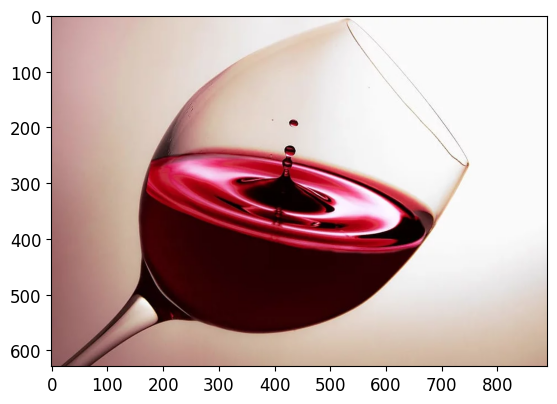

In [16]:
plt.imshow(image)

#### 3. Modifica la estructura de la imagen
Queremos que cada pixel sea una observación por lo que tenemos que transformar nuestra imagen de un vector de forma (alto, ancho, color) a (alto x ancho, color). Color será siempre 3, que son los tres canales de los colores.

Ej: (300, 400, 3) -> (120000, 3)

In [8]:
image_array = np.array(image)  # Forma: (alto, ancho, 3)

# Normalizar a [0, 1] si la imagen está en [0, 255]
if image_array.max() > 1.0:
    image_array = image_array / 255.0

In [9]:
image_array.reshape(-1,3).shape

(559810, 3)

#### 4. K-means
Haz un k-means con la imagen de entrada (Con la nueva forma que le hemos dado). K será el número de colores que quieras que tenga tu imagen de salida

In [10]:
X = image_array.reshape(-1,3)

In [18]:
kmeans = KMeans(n_clusters=10, n_init=10, random_state=10).fit(X)

In [22]:
kmeans.labels_

array([2, 2, 2, ..., 2, 2, 2], shape=(559810,), dtype=int32)

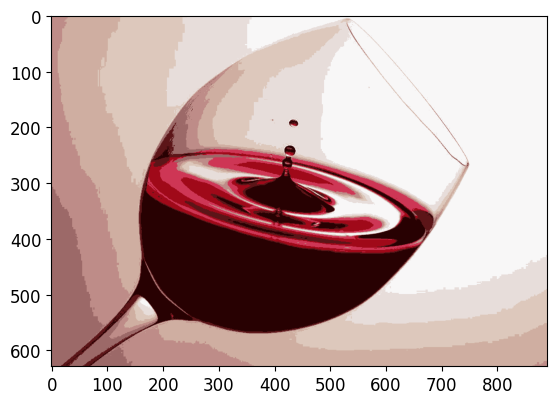

In [19]:
segmented_img = kmeans.cluster_centers_[kmeans.labels_]
segmented_img = segmented_img.reshape(image_array.shape)
#print("segmented_img:", segmented_img)

plt.imshow(segmented_img)

#### 5. Sustituye cada valor por su centroide

Una vez hemos entrenado el kmeans entre otros parametros de salida tiene `cluster_centers_` y `labels_`. Utilizlos para crear una nueva imagen (recuerda que las imagenes simplemente son vectores numéricos) en la que cada pixel se sustituye por su centroide correspondiente.

In [23]:
centroides = kmeans.cluster_centers_  # Forma: (n_clusters, 3)
etiquetas = kmeans.labels_           # Forma: (n_píxeles,)

In [24]:
# Sustituir cada píxel por su centroide
imagen_segmentada = centroides[etiquetas]  # Forma: (n_píxeles, 3)

#### 6. Modifica la estructura de la imagen
Para trabajar con el k-means requeriamos que la imagen original fuese un solo vector, ahora como queremos volver a tener la imagen para volver mostrarla debemos hacer el proceso inverso a el paso 3. (Si has guardado la forma de la imagen original te será más facil hacer este paso)

In [26]:
alto, ancho, canales = image.shape  # Forma original
imagen_segmentada = imagen_segmentada.reshape(alto, ancho, canales)

imagen_segmentada.shape

(629, 890, 3)

#### 7. Imprime y guarda en tu ordenador la imagen resultante

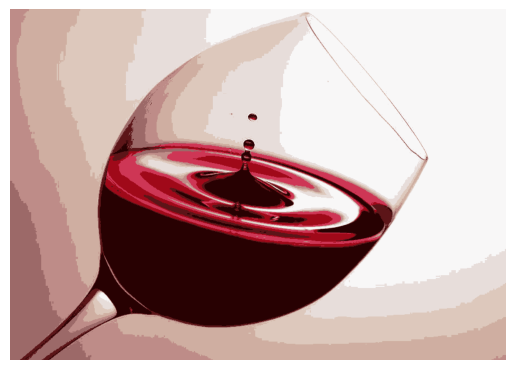

In [27]:
plt.imshow(imagen_segmentada)
plt.axis('off')
plt.show()

In [29]:
plt.imsave("data/imagen_segmentada.png", imagen_segmentada)

#### 8. Crea una función
Crea una función que tenga como argumentos de entrada una imagen, el numero de colores que quieres que tenga, y si se quiere guardar o mostrar por pantalla

In [ ]:
image_array = np.array(image)  # Forma: (alto, ancho, 3)

# Normalizar a [0, 1] si la imagen está en [0, 255]
if image_array.max() > 1.0:
    image_array = image_array / 255.0

In [39]:
def cluster_colores(img, k):
     image = plt.imread (img) 
     image_array = np.array(image)
     
     if image_array.max() > 1.0:
          image_array = image_array / 255.0
     
     X=image_array.reshape(-1,3) 
     kmeans = KMeans (n_clusters=k, n_init=10, random_state=10).fit(X)
     img_seg = kmeans.cluster_centers_[kmeans.labels_]
     img_seg = img_seg.reshape(image_array.shape)
     plt.imshow(img_seg)
     plt.imsave('data/imagen_procesada.jpg', img_seg)

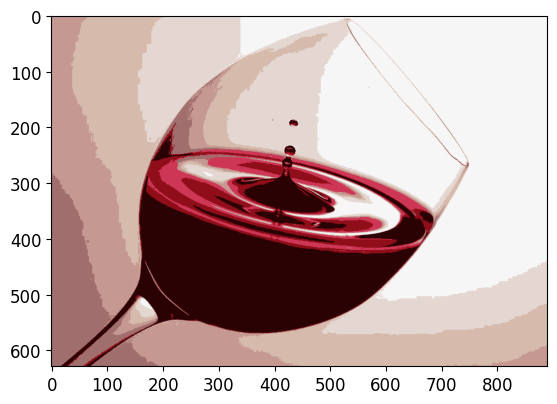

In [40]:
path_img = 'data/vino.jpg'
k=8
cluster_colores(path_img,k)